# Lattice of attractors and the nontrivial Conley-Morse graph

This tutorial demonstrates the graph derivations in `CMGDB.morse_lattice`
on **simple 2-D maps**. Given a Morse graph (the partial order of an
isolated invariant set's recurrent components), it shows how to:

1. take the **transitive closure / reduction** of the order,
2. build the **lattice of attractors** and **lattice of repellers**, and
3. extract the **nontrivial Conley-Morse graph** by pruning Morse sets
   whose Conley index is trivial.

Everything runs on the pure-Python `MorseGraph` parsed from CMGDB's DOT
output — no DSGRN or pychomp.

In [1]:
import math
import tempfile

import graphviz

import CMGDB
from CMGDB.morse_graph_parser import MorseGraph


def morse_graph_from_model(model, conley=True):
    """Run CMGDB and parse its DOT output into a MorseGraph, returning also the
    underlying CMGDB Morse-graph and map-graph objects."""
    compute = CMGDB.ComputeConleyMorseGraph if conley else CMGDB.ComputeMorseGraph
    cmgdb_mg, map_graph = compute(model)
    dot = CMGDB.PlotMorseGraph(cmgdb_mg).source
    with tempfile.NamedTemporaryFile("w", suffix=".dot", delete=False) as f:
        f.write(dot)
        path = f.name
    return MorseGraph.from_dot(path), cmgdb_mg, map_graph


def render(graph, rankdir="TB"):
    """Render any object exposing .nodes / .edges / .labels (a MorseGraph or a
    DerivedGraph) as a Graphviz diagram."""
    lines = [f"digraph G {{ rankdir={rankdir}; node [shape=box, style=rounded];"]
    for n in graph.nodes:
        lines.append(f'  {n} [label="{graph.labels.get(n, n)}"];')
    for u in graph.nodes:
        for v in graph.edges.get(u, []):
            lines.append(f"  {u} -> {v};")
    lines.append("}")
    return graphviz.Source("\n".join(lines))


## A simple contracting map

We start with two decoupled 1-D contractions,
$f(x_0, x_1) = \left(\tfrac{x_0}{2 - x_0},\ \tfrac{x_1}{2 - x_1}\right)$
on $[0, 1.2]^2$. CMGDB returns four Morse sets: an attractor, two saddles,
and a repeller, all with a *nontrivial* Conley index.

In [2]:
def contraction(x):
    return [x[0] / (2.0 - x[0]), x[1] / (2.0 - x[1])]

def contraction_box_map(rect):
    return CMGDB.BoxMap(contraction, rect, padding=False)

model = CMGDB.Model(6, 10, 4, 10000, [0.0, 0.0], [1.2, 1.2], contraction_box_map)
mg, cmgdb_mg, map_graph = morse_graph_from_model(model)

print(f"{len(mg.nodes)} Morse sets; attractor (minimal) nodes: {sorted(mg.minimal)}")
for n in mg.nodes:
    print(f"  node {n}: Conley index {mg.labels[n].split(' : ')[1]}")

4 Morse sets; attractor (minimal) nodes: [0]
  node 0: Conley index (x-1, 0, 0)
  node 1: Conley index (0, x-1, 0)
  node 2: Conley index (0, x-1, 0)
  node 3: Conley index (0, 0, x-1)


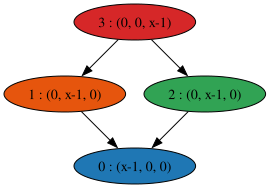

In [3]:
# The Morse graph as CMGDB draws it (edges point from higher to lower Morse sets).
CMGDB.PlotMorseGraph(cmgdb_mg)

## Transitive closure and reduction

The Morse graph is a DAG. `transitive_closure` lists every node reachable
from each node; `transitive_reduction` keeps only the *covering* edges (the
Hasse diagram). The reduction is the primitive underlying both the lattice
and the nontrivial-graph constructions below.

In [4]:
from CMGDB.morse_lattice import transitive_closure, transitive_reduction

closure = transitive_closure(mg.nodes, mg.edges)
reduced = transitive_reduction(mg.nodes, mg.edges)
for n in mg.nodes:
    print(f"node {n}: reaches {sorted(closure[n])}, covers {sorted(reduced[n])}")

node 0: reaches [], covers []
node 1: reaches [0], covers [0]
node 2: reaches [0], covers [0]
node 3: reaches [0, 1, 2], covers [1, 2]


## Lattice of attractors

An *attractor* of the Morse graph is a downset (a set of Morse nodes closed
under following edges). `lattice_of_attractors` enumerates every attractor
(the join-closure of the principal downsets) and returns their inclusion
order as a transitively-reduced Hasse diagram. Each lattice vertex is
labelled with the set of Morse nodes it contains.

In [5]:
from CMGDB.morse_lattice import lattice_of_attractors

latt = lattice_of_attractors(mg)
print(f"{len(latt.nodes)} attractors:")
for v in latt.nodes:
    print(f"  {latt.labels[v]:>14s}   (Morse nodes {sorted(latt.sets[v])})")

6 attractors:
             { }   (Morse nodes [])
             {0}   (Morse nodes [0])
          {0, 1}   (Morse nodes [0, 1])
          {0, 2}   (Morse nodes [0, 2])
       {0, 1, 2}   (Morse nodes [0, 1, 2])
    {0, 1, 2, 3}   (Morse nodes [0, 1, 2, 3])


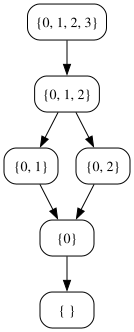

In [6]:
# Largest attractor at the top, the empty attractor at the bottom.
render(latt)

## Lattice of repellers

Dually, `lattice_of_repellers` computes the lattice of repellers (upsets of
the Morse graph), obtained by running the same construction on the
transposed order.

6 repellers:
             { }   (Morse nodes [])
             {3}   (Morse nodes [3])
          {1, 3}   (Morse nodes [1, 3])
          {2, 3}   (Morse nodes [2, 3])
       {1, 2, 3}   (Morse nodes [1, 2, 3])
    {0, 1, 2, 3}   (Morse nodes [0, 1, 2, 3])


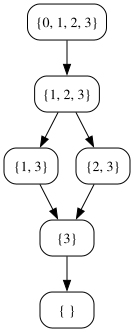

In [7]:
from CMGDB.morse_lattice import lattice_of_repellers

rep = lattice_of_repellers(mg)
print(f"{len(rep.nodes)} repellers:")
for v in rep.nodes:
    print(f"  {rep.labels[v]:>14s}   (Morse nodes {sorted(rep.sets[v])})")
render(rep)

## The nontrivial Conley-Morse graph

At a coarse subdivision CMGDB often reports **spurious transient Morse
sets** — regions that look recurrent in the outer approximation but carry a
**trivial Conley index** $(0, 0, \dots)$, so they enclose no real invariant
set. `nontrivial_cmgraph` removes them and rebuilds the induced order
(an edge survives even when its only path ran through a pruned node).

We switch to the 2-D Leslie population map
$f(x_0, x_1) = \big((\theta x_0 + \theta x_1)\,e^{-0.1(x_0+x_1)},\ 0.7\,x_0\big)$,
$\theta = 23.5$, computed at a coarse grid so several trivial transients appear.

In [8]:
def leslie(x):
    theta = 23.5
    return [(theta * x[0] + theta * x[1]) * math.exp(-0.1 * (x[0] + x[1])), 0.7 * x[0]]

def leslie_box_map(rect):
    x0_lo, x1_lo, x0_hi, x1_hi = rect
    corners = [leslie([x0_lo, x1_lo]), leslie([x0_hi, x1_lo]),
               leslie([x0_lo, x1_hi]), leslie([x0_hi, x1_hi])]
    y0 = [c[0] for c in corners]; y1 = [c[1] for c in corners]
    return [min(y0), min(y1), max(y0), max(y1)]

leslie_model = CMGDB.Model(20, 20, 20, 10000, [-0.001, -0.001], [110.0, 77.0], leslie_box_map)
lmg, lcmgdb, lmap = morse_graph_from_model(leslie_model)
print(f"Raw Morse graph: {len(lmg.nodes)} Morse sets")
for n in lmg.nodes:
    print(f"  node {n}: {lmg.labels[n].split(' : ')[1]}")

Raw Morse graph: 10 Morse sets
  node 0: (x^3-1, 0, 0)
  node 1: (0, x^3-1, 0)
  node 2: (0, 0, 0)
  node 3: (0, 0, 0)
  node 4: (0, 0, 0)
  node 5: (0, 0, 0)
  node 6: (0, 0, 0)
  node 7: (0, 0, 0)
  node 8: (0, 0, 0)
  node 9: (0, 0, x-1)


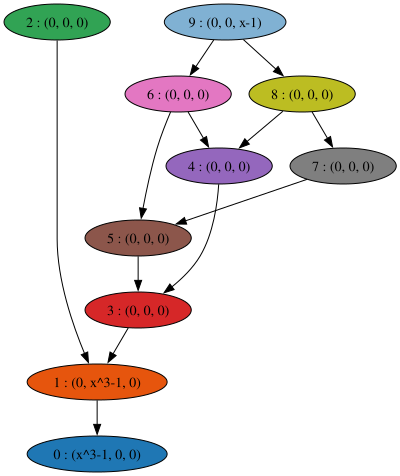

In [9]:
CMGDB.PlotMorseGraph(lcmgdb)

Nontrivial Conley-Morse graph: 3 nodes (pruned 7 trivial transients)
  node 0: (x^3-1, 0, 0)
  node 1: (0, x^3-1, 0)
  node 9: (0, 0, x-1)


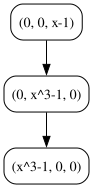

In [10]:
from CMGDB.morse_lattice import nontrivial_cmgraph

nt = nontrivial_cmgraph(lmg)
print(f"Nontrivial Conley-Morse graph: {len(nt.nodes)} nodes "
      f"(pruned {len(lmg.nodes) - len(nt.nodes)} trivial transients)")
for n in nt.nodes:
    print(f"  node {n}: {nt.labels[n]}")
render(nt)